# Weight Initialization

- Kushal Kharel

*Note: Go through activation function article to understand this*

Activation functions and weight initialization are two sides of the same coin.
We know that a neural network calculates

$$
z = \sum w_i x_i + b
$$

Weight initialization is the art of setting those initial $w$ values so that $z$ doesn't become too large (exploding) or too small (vanishing) as it passes through the layers. Think of weight initialization as setting the volume of each neuron before the music (data) starts playing.

To understand initialization, we must look at the variance of the outputs. If we have a layer with $n$ inputs, the variance of the output $z$ is:

$$
Var(z) = n Var(w) Var(x)
$$

If $Var(z)$ is not kept close to the variance of the input, the signal will either grow exponentially or die out across layers.

At first glance, setting all weights to zero, $w = 0$, seems logical and clean. However, in deep learning research, this is the most common reason a model fails to learn entirely.

## 1. Zero Initialization (The "Symmetry" Trap)

We mention above that a neuron calculates $z$. If we initialize all weights $W$ in a layer to zero then:
- During forward pass, every neuron in a hidden layer will produce the exact same output (typically 0 or the bias $b$).
- DUring backward pass/backpropagation, the gradient of the loss with respect to the weights, $\frac{\partial L}{\partial w}$, depends on the input and the activation. Since every neuron produced the same output, every neuron receives the identical gradient update.

Mathematically, if $w_1=w_2=0$, then after one update:
$$
w_{1(new)} = 0 - \eta \nabla L
$$

$$
w_{2(new)} = 0 - \eta \nabla L
$$

$w_{1(new)}$ will always equal $w_{2(new)}$. This is known as the symmetry problem. Even after 1000 epochs, our deep neuron layer will behave like a single neuron because they are all doing exactly the same thing. We wasted the representational power we sought to gain with non-linear activation.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# showing how model flatlines with zero weights

# simple linear layer
layer = nn.Linear(in_features=10, out_features=5)

# force zero initialization
nn.init.zeros_(layer.weight)
nn.init.zeros_(layer.bias)

print("Initial Weights (All Zeros):\n", layer.weight)

# simulating forward pass with random data
input_data = torch.randn(1, 10)
output = layer(input_data)
print("\nLayer Output(Notice all neurons give the same value):")
print(output)



Initial Weights (All Zeros):
 Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], requires_grad=True)

Layer Output(Notice all neurons give the same value):
tensor([[0., 0., 0., 0., 0.]], grad_fn=<AddmmBackward0>)


Now that we have established that zero initialization createa s symmetry trap, random initialization was introduced to break symmetry. This was the industry standard for years, but as models grew deeper, researchers discovered a fundamental mathematical flaw that nearly killed deep learning in the early 2000s.

## 2. Random Normal Initialization (The "Goldilocks Dilemma)

To break symmetry, we sample weights from a Gaussian distribution, $w \sim \mathcal{N}(0, \sigma^2)$. Usually, we would pick a small constant like $\sigma = 0.01$.

Now lets look at a single layer output $y = \sum_{i=1}^n w_ix_i$. Assuming $x$ and $w$ are independent and have a mean of zero, the variance of the output $y$ is calcualted as:

$$
Var(y) = n_{in} Var(w) Var(x)
$$

where n is the number of input neurons (fan-in). If we have a deep network with $L$ layers, the variance at the final layer becomes,

$$
Var(Output) = Var(Input) [n Var(w)]^L
$$

From the equation above, if $n Var(w) < 1$ (e.g., small weights), the variance shrinks exponentially. By layer 50, the signal is effectively 0. The model learns nothing because the gradients become too small to update anything. On the other hand, if $n Var(w) > 1$, the variance grows exponentially. The activation becomes ```NaN``` or infinity and the model crashes.

In [ ]:
# visualizing the collapse (what happens to the signal (the variance of activations) when we use constant scale of 0.01 vs 1)

def simulate_variance(layers=50, n_in=512, init_std = 0.01):
  variances = []
  x = np.random.randn(n_in)
  current_x = x
  for i in range(layers):
    w = np.random.normal(0, init_std, (n_in, n_in))
    current_x = w @ current_x
    variances.append(np.var(current_x))
  return variances

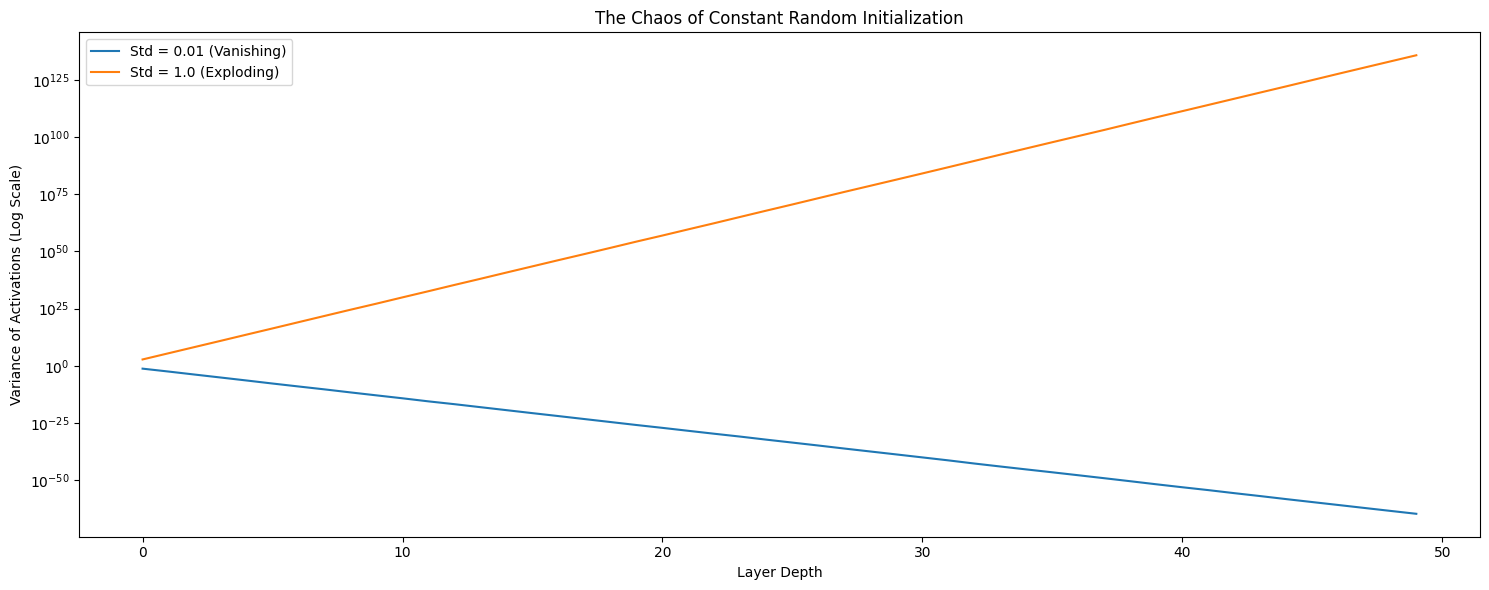

In [ ]:
v_001 = simulate_variance(layers=50, init_std=0.01)
v_1 = simulate_variance(layers=50, init_std=1.0)

plt.figure(figsize=(15, 6))
plt.plot(v_001, label='Std = 0.01 (Vanishing)')
plt.plot(v_1, label='Std = 1.0 (Exploding)')
plt.yscale('log')
plt.xlabel('Layer Depth')
plt.ylabel('Variance of Activations (Log Scale)')
plt.title('The Chaos of Constant Random Initialization')
plt.legend()
plt.grid(False)
plt.tight_layout()
# plt.savefig('random_init_variance.png')
plt.show()

In the plot above, notice the blue line and see how the signal vanishes almost immediately. By layer 10, the activations are so small that the computer can barely represent them. The orange line shows the signal exploding. Within a few layers, the values are so large they exceed the numerical limits of the hardware.

In [ ]:
# why guessing a random constant (like 0.01) is dangerous

def check_variance_flow(std_value):
  x = torch.randn(1, 512) # Input with Variance 1

  for i in range(50):
    layer = nn.Linear(512, 512, bias=False)
    # Initialize with constant scale
    nn.init.normal_(layer.weight, mean=0.0, std=std_value)
    x = layer(x)

    if torch.isnan(x).any():
      return f"Layer {i}: Exploded to NaN"

  return f"Final Variance after 50 layers: {x.var().item():.4e}"

print("Small Weights:", check_variance_flow(0.01))
print("Large Weights:", check_variance_flow(1.0))

Small Weights: Final Variance after 50 layers: 0.0000e+00
Large Weights: Layer 28: Exploded to NaN


Here, we did break the symmetry. Every neuron is now doing something different. But, there is a new problem now. We are fighting against, $n$, the number of inputs. A weight scale that works for a layer with 10 neurons will fail for a layer with 1000 neurons. We need a way to set the weight variance automatically based on the size of the layer $n$ which leads us to Xavier Initialization.

## 3. Xavier (Glorot) Initialization

The Xavier derivation relies on a critical assumption: *The activation function is linear in its middle range*. Functions like Tanh and Sigmoid satisfy this assumption. However, there is a hidden trap with sigmoid that researchers must look out for.

Let's move on to the mathematics behind this initialization. To keep the signal alive, Glorot and Bengio looked at two constraints:

- Forward Pass: $Var(a^{(l)}) = Var(a^{(l-1)})$ (Signal doesn't die).
- Backward Pass: $Var(\frac{\partial L}{\partial a^{(l)}}) = Var(\frac{\partial L}{\partial a^{(l-1)}})$ (Gradients don't die)

And they found that for a linear activation, the variance of the weights should be:

$$
Var(W) = \frac{2}{n_{in} + n_{out}}
$$

Because functions like Tanh sqaushes the variance slightly, we often add a multiplier called the gain.

$$
\sigma = gain \sqrt(\frac{2}{n_{in} + n_{out}})
$$

For linear activation $gain = 1$ and for Tanh, $gain \approx \frac{5}{3}$ to account for the curvature.


In [ ]:
# Why Tanh is better than Sigmoid for Xavier?

def sigmoid(x):
  return 1/(1+np.exp(-x))

def tanh(x):
  return np.tanh(x)

In [ ]:
def simulate_activations(activation_fn, init_type='xavier', layers=10, n_in=512):
  x = np.random.randn(n_in)
  means = []
  stds = []
  current_x = x
  for i in range(layers):
    if init_type == 'xavier':
      std = np.sqrt(1.0 / n_in) # Simplified Xavier
    else:
      std = 0.01
    w = np.random.normal(0, std, (n_in, n_in))
    z = w @ current_x
    current_x = activation_fn(z)
    means.append(np.mean(current_x))
    stds.append(np.std(current_x))

  return means, stds

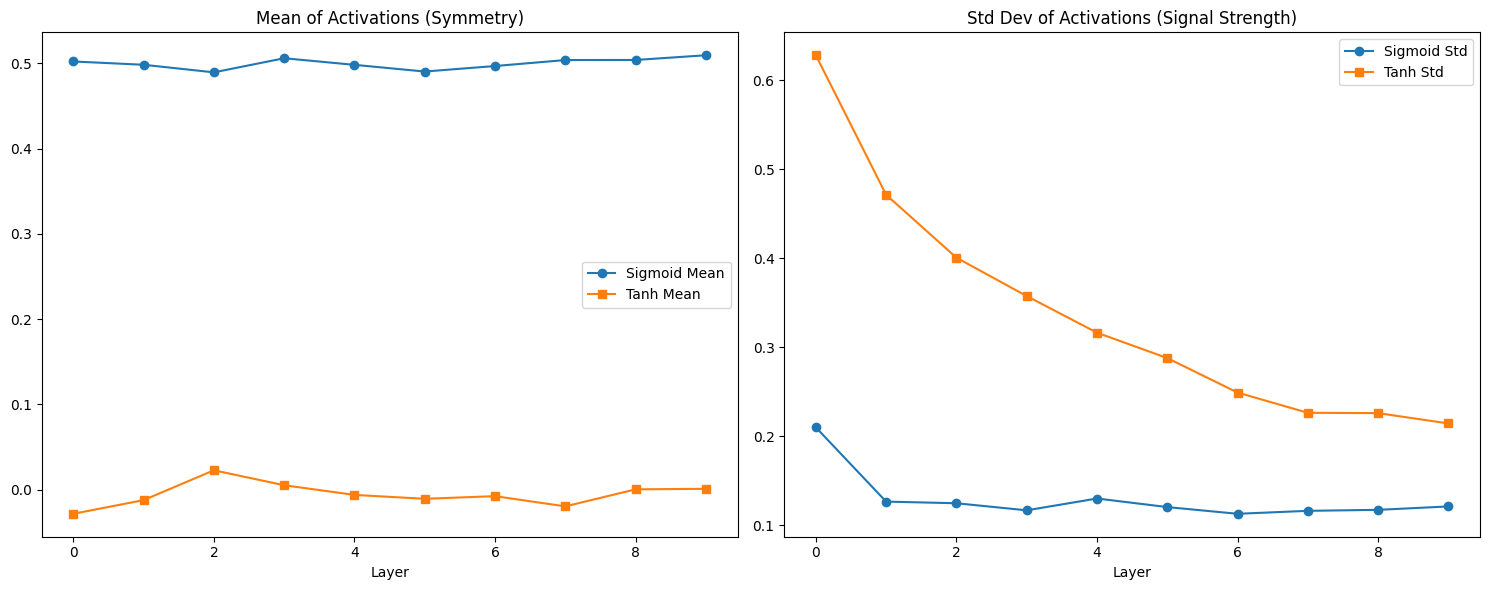

In [ ]:
# Compare Sigmoid vs Tanh with Xavier
s_means, s_stds = simulate_activations(sigmoid, 'xavier', layers=10)
t_means, t_stds = simulate_activations(tanh, 'xavier', layers=10)

plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
plt.plot(s_means, label='Sigmoid Mean', marker='o')
plt.plot(t_means, label='Tanh Mean', marker='s')
plt.title('Mean of Activations (Symmetry)')
plt.xlabel('Layer')
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(s_stds, label='Sigmoid Std', marker='o')
plt.plot(t_stds, label='Tanh Std', marker='s')
plt.title('Std Dev of Activations (Signal Strength)')
plt.xlabel('Layer')
plt.legend()
plt.grid(False)

plt.tight_layout()
# plt.savefig('xavier_sigmoid_vs_tanh.png')
plt.show()

From the left plot we can see that tanh is symmetric around zero. The mean stays at 0 across laters. On the other hand, for signmoid, the mean is always positive adn it quickly shifts to 0.5, pushing subsequent layers into saturation. From the right plot, we notice that the standard deviation (signal strength) for sigmoid is much smaller and collapses faster than Tanh.

Xavier Initialization was actually the reason researchers switched from sigmoid to tanh in early 2010s. It solved the variance problem but Sigmoid's non-zero mean still caused the network to slow down.

In [ ]:
# verification of gain: we use gain to adjust the initialization for the specific activation function used

# determine the gain for activation
gain_tanh = nn.init.calculate_gain('tanh')
gain_sigmoid = nn.init.calculate_gain('sigmoid')

print(f"Gain for Tanh: {gain_tanh:.2f}")
print(f"Gain for Sigmoid: {gain_sigmoid:.2f}")

# Apply with gain
layer = nn.Linear(512, 512)
nn.init.xavier_normal_(layer.weight, gain=gain_tanh)

Gain for Tanh: 1.67
Gain for Sigmoid: 1.00


Parameter containing:
tensor([[ 0.0060, -0.0200, -0.0787,  ...,  0.0773,  0.0163,  0.0870],
        [ 0.0290,  0.0891,  0.0826,  ...,  0.0747,  0.0551, -0.0262],
        [-0.0409, -0.1147,  0.0703,  ..., -0.0441,  0.0884,  0.1627],
        ...,
        [ 0.0418,  0.0404,  0.0324,  ..., -0.1154, -0.0427, -0.0757],
        [ 0.1626,  0.1551, -0.0500,  ...,  0.1295,  0.0714,  0.1027],
        [ 0.0188, -0.0543, -0.0879,  ...,  0.1163,  0.0818, -0.1204]],
       requires_grad=True)

Glorot keeps variance constant across layers. It works best when the activation function is symmetric around zero. The limitation of it is that it fails for ReLU because ReLU is "half-dead" by design, that is, it discards all negative values, which breaks the variance assumption.

This brings us to our next initialization method *He (Kaiming) Initialization* proposed by Kaiming He et al. in 2015

## 4. He (Kaiming Initialization)

In activation functions article, we discussed about ReLU. The function is given by,

$$
f(x) = max(0,x)
$$

which is non-linear and solves the vanishing gradient problem of sigmoid. However, ReLU has a dark side, it kills exactly half of its input variance specially the negative half.

Lets recall the variance propagation formula:

$$
Var(y) = n_{in} Var(w) Var(x)
$$

When we use ReLU, the distribution of $y$ is truncated at zero. If the input to ReLU is symmetric around zero then:

$$
Var(ReLU(y)) \approx \frac{1}{2}Var(y)
$$

If we use Xavier initialization $(Var(w) = \frac{1}{n_{in}})$, the variance at each layer becomes:

$$
Var(a^{(l)}) = \frac{1}{2} \cdot n_{in} \cdot \frac{1}{n_{in}} \cdot Var(a^{(l-1)}) = \frac{1}{2} Var(a^{(l-1)})
$$

This means with Xavier, the signal strength is halved at every single layer. In a 50-layer ResNet, the signal would be $0.5^{50}$ times its original size which is essentially disappearing. To fix this issue, Kaiming He proposed doubling the weight variance to compensate for the lost-half.

$$
Var(w) = \frac{2}{n_{in}}
$$

$$
Standard Deviation (\sigma) = \sqrt(\frac{2}{n_{in}})
$$


In [ ]:
def relu(x):
  return np.maximum(0, x)

def simulate_relu_init(init_type='xavier', layers=50, n_in=512):
  x = np.random.randn(n_in)
  variances = []
  current_x = x
  for i in range(layers):
    if init_type == 'xavier':
      std = np.sqrt(1.0 / n_in) # Xavier std = sqrt(1/n_in)
    elif init_type == 'he':
      std = np.sqrt(2.0 / n_in) # He std = sqrt(2/n_in)
    else:
      std = 0.01

    w = np.random.normal(0, std, (n_in, n_in))
    z = w @ current_x
    current_x = relu(z)
    variances.append(np.var(current_x))

  return variances

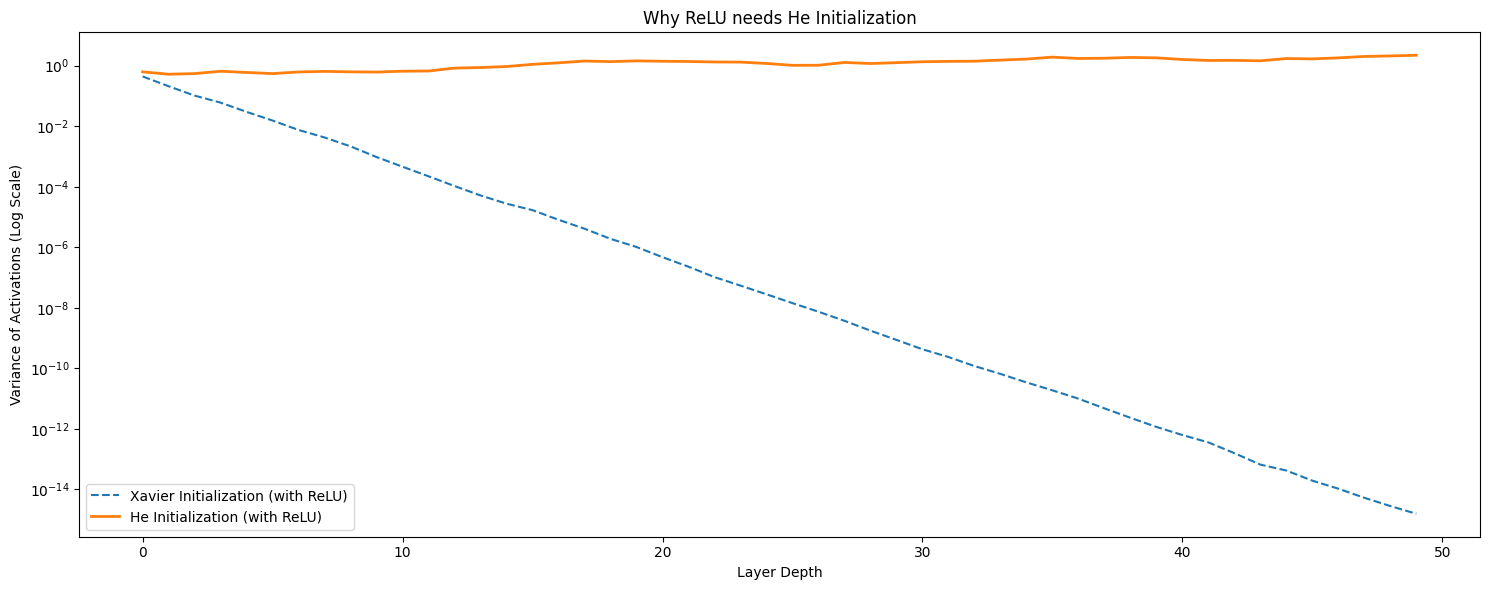

In [ ]:
v_xavier_relu = simulate_relu_init('xavier', 50)
v_he_relu = simulate_relu_init('he', 50)

plt.figure(figsize=(15, 6))
plt.plot(v_xavier_relu, label='Xavier Initialization (with ReLU)', linestyle='--')
plt.plot(v_he_relu, label='He Initialization (with ReLU)', linewidth=2)
plt.yscale('log')
plt.xlabel('Layer Depth')
plt.ylabel('Variance of Activations (Log Scale)')
plt.title('Why ReLU needs He Initialization')
plt.legend()
plt.grid(False)
# plt.savefig('he_vs_xavier_relu.png')
plt.tight_layout()
plt.show()

From the plot above,we can see that even though Xavier was stable for tanh, the variance consistently drops when paired with ReLU. By layer 50, the signal is nearly dead. On the other hand, the variance stays perfectly horizontal with He initialization. Factor of 2 perfectly cancels out factor of 0.5 from the ReLU activation. This is what mode training deep networks like ResNet-101 possible.



In [ ]:
# default for almost all convolutional and dense layers

layer = nn.Linear(512, 512)

# He Normal Initialization (Kaiming Normal)
# mode='fan_in' uses n_in, nonlinearity='relu' sets the gain automatically
nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')

# He Uniform Initialization
nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')

print(f"He calculated a Weight Std Dev of: {layer.weight.std().item():.4f}")
# sqrt(2 / 512)

He calculated a Weight Std Dev of: 0.0624


To conclude, weight initialization is the bridge between neural network architecture and optimization. Through the deep dive in this article, we have established three fundamental laws:

- *The Law of Symmetry*: Weights must never be initialized to a constant value like zero. Symmetry is the enemy of learning, neurons must be born different so they can specialize in different features.
- *The Law of Variance Preservation*: The core mathematical goal of initialization is to ensure that the variance of activations remains constant from the first layer to the last. If variance shrinks then the signal vanishes and if it grows then the signal explodes.
= *The Law of Co-dependence*: We cannot choose an initialization strategy without looking at the activation function. Xavier is the partner for Sigmoid/Tanh and He is the partner for ReLU/Leaky ReLU.

While the three laws provide a mathematical safety ney for training deep networks, modern research ahs shifted toward architectural solutions that make models even more robust to initial weight values. As a next reading, consider exploring these advanced concepts:

- *Batch Normalization:* The most significant leap in managing signal variance was the introduction of Batch Normalization (BN). Instead of relying solely on a perfect "Goldilocks" initialization, BN recenters and re-scales the inputs to every layer during training. By doing so, it significantly reduces the internal covariate shift, allowing us to use higher learning rates and making the network much less sensitive to the specific initialization strategy used. While BN makes trainig easier, it introduces dependencies between samples in a batch and can be computationally expensive.

- *Residual Connections:* In extremely deep networks, even the best initialization can struggle to preserve the gradient signal. Residual connections (skip connections) allow the gradient to bypass layers during backpropagation. By providing a direct highway for the signal, ship connections enure that even if a layer's weights are poorly initialized, the overall network can still flow information effectively,

- *Data-Dependent Initialization:* Emerging techniques liek LSUV (Layer-sequential Unit-variance) take a more automated approach. Instead of using a fixed formula like Xavier or He, these algorithms perform a single forward pass with a batch of data and iteratively adjust each layer;s weights until the ouput varianve is exactly 1. This is particularly useful for novel or custom activation functions where a standard mathematical proof for initialization doesn't exist yet.

In the previous article we discussed the activation function aka gatekeepers and in this article we discussed starting weights. Now, in the next article we will discuss the engine that moves those weights towards the answer. The next article will be on Optimization since we already know how to activate a neuron and how to initialize it.